<a href="https://colab.research.google.com/github/Aaricis/Hung-yi-Lee-ML2022/blob/main/HW6/ML_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 思路
PS: 本次作业的提交平台为JudgeBoi，非台大的学生不能提交。出于学习的目的，代码仅实现hints，但是最终的效果不能保证。

另外，Sample Code没有给出FID和AFD的计算。出于学习的目的，作者自己补充了相应的计算代码，用于观察不同优化措施带来的效果，跟JudgeBoi的评判机制不一定一致。

## Simple Baseline(FID ≤ 30000, AFD ≥ 0)
跑一遍Sample Code。

FID: 396.80337487215184

AFD: 0.085

## Medium Baseline (FID ≤ 12000, AFD ≥ 0.4)
FID: 184.41336801146772

AFD: 0.573

- 修改`n_epoch`，`n_critic`：
```python
"n_epoch": 50,
"n_critic": 2
```
- 训练GAN容易发生梯度爆炸，因此引入梯度裁剪：
```python
import torch.nn.utils as utils
utils.clip_grad_norm_(self.D.parameters(), max_norm=1.0)
utils.clip_grad_norm_(self.G.parameters(), max_norm=1.0)
```







## Strong Baseline(FID ≤ 10000, AFD ≥ 0.5)





### WGAN
FID: 166.73857250731453

AFD: 0.65
- 去除梯度裁剪；
- 从Discriminator中移除最后一个Sigmiod层；
- 修改loss函数loss_D、loss_G；
```python
loss_D = -torch.mean(r_logit) + torch.mean(f_logit)
loss_G = -torch.mean(self.D(f_imgs))
```
- 训练Discriminator时，进行权重裁剪：
```python
for p in self.D.parameters():
    p.data.clamp_(-self.config["clip_value"], self.config["clip_value"])
```
- 使用RMSProp optimizer;
```python
self.opt_D = torch.optim.RMSprop(self.D.parameters(), lr=self.config["lr"])
self.opt_G = torch.optim.RMSprop(self.G.parameters(), lr=self.config["lr"])
```
- config中添加clip_value项;
```python
config = {
    "model_type": "WGAN",
    "batch_size": 64,
    "lr": 1e-4,
    "n_epoch": 50,
    "n_critic": 2,
    "z_dim": 100,
    "workspace_dir": workspace_dir, # define in the environment setting
    "clip_value": 1.0
}
```
训练下来发现效果不稳定，FID、AFD略有提升。



### WGAN-GP
FID: 169.90538676508262

AFD: 0.68

在WGAN的基础上：
- 用gradient penalty代替权重裁剪；
```python
def gp(self, r_imgs, f_imgs):
    Tensor = torch.cuda.FloatTensor
    alpha = Tensor(np.random.random((r_imgs.size(0), 1, 1, 1)))
    interpolates = (alpha*r_imgs + (1 - alpha)*f_imgs).requires_grad_(True)
    d_interpolates = self.D(interpolates)
    fake = Variable(Tensor(r_imgs.shape[0]).fill_(1.0), requires_grad=False)
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(1, dim=1) - 1)**2).mean()
    return gradient_penalty
```
- 修改loss函数loss_D；
```python
gradient_penalty = self.gp(r_imgs, f_imgs)
loss_D = -torch.mean(r_logit) + torch.mean(f_logit) + gradient_penalty
```

- `nn.InstanceNorm2d`代替`nn.InstanceNorm2d`；
```python
def conv_bn_lrelu(self, in_dim, out_dim):
    return nn.Sequential(
        nn.Conv2d(in_dim, out_dim, 4, 2, 1),
        # nn.BatchNorm2d(out_dim),
        nn.InstanceNorm2d(out_dim),
        nn.LeakyReLU(0.2),
    )
```

相比GAN和WGAN，训练稳定了很多，可以观察到Anime face从杂讯中慢慢生成出来。

## Boss Baseline(FID ≤ 9000, AFD ≥ 0.6)
直接使用[stylegan2-pytorch](https://github.com/lucidrains/stylegan2-pytorch)训练并生成图片。

```python
!pip install stylegan2_pytorch==1.9.0
```

默认的`num-train-steps`为150000。实测Kaggle最多只能运行12h，约4000个step，生成图片的效果并不是很好。有条件的同学可以尝试训练10000个step再生成图片，应该能获得不错的效果。

```python
# 训练
!stylegan2_pytorch \
    --data ./faces \
    --name my_stylegan2 \
    --image-size 64 \
    --batch-size 64 \
    --save-every 200 \
    --num-train-steps 4000
```

```python
# 推理
!stylegan2_pytorch \
    --name my_stylegan2 \
    --generate \
    --num_generate 16 \
    --results-dir ./output
```
stylegan2_pytorch `--generate` 默认会把生成图拼成一个图像网格，不是单张图片，需要自行切片。
```python
temp_dataset = get_dataset(os.path.join("./output", 'default'))
for i in range(len(temp_dataset)):
    torchvision.utils.save_image(temp_dataset[i], os.path.join("./output", f'{i+1}.jpg'))
```


# Homework 6 - Generative Adversarial Network
This is the sample code for hw6 of 2022 Machine Learning course in National Taiwan University.

In this sample code, there are 5 sections:
1. Environment setting
2. Dataset preparation
3. Model setting
4. Train
5. Inference

Your goal is to do anime face generation, if you have any question, please discuss at NTU COOL

# Environment setting
In this section, we will prepare for the dataset and set some environment variable

## Download Dataset

In [1]:
# get dataset from huggingface hub
!curl -s https://packagecloud.io/install/repositories/github/git-lfs/script.deb.sh | bash
!apt-get install git-lfs
!git lfs install
!git clone https://huggingface.co/datasets/LeoFeng/MLHW_6
!unzip ./MLHW_6/faces.zip -d .

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: ./faces/20071.jpg       
  inflating: ./faces/26595.jpg       
  inflating: ./faces/49584.jpg       
  inflating: ./faces/43981.jpg       
  inflating: ./faces/10666.jpg       
  inflating: ./faces/58463.jpg       
  inflating: ./faces/16295.jpg       
  inflating: ./faces/21060.jpg       
  inflating: ./faces/4403.jpg        
  inflating: ./faces/16084.jpg       
  inflating: ./faces/65220.jpg       
  inflating: ./faces/45567.jpg       
  inflating: ./faces/63132.jpg       
  inflating: ./faces/67431.jpg       
  inflating: ./faces/29426.jpg       
  inflating: ./faces/71111.jpg       
  inflating: ./faces/21515.jpg       
  inflating: ./faces/60713.jpg       
  inflating: ./faces/69169.jpg       
  inflating: ./faces/47845.jpg       
  inflating: ./faces/67653.jpg       
  inflating: ./faces/46503.jpg       
  inflating: ./faces/52996.jpg       
  inflating: ./faces/62068.jpg       
  inflating: ./faces/36319.jpg       
  inflating: ./faces/35

## Other setting

In [2]:
# import module
import os
import glob
import random
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch import optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils as utils
import torch.autograd as autograd

import matplotlib.pyplot as plt
import numpy as np
import logging
from tqdm import tqdm


# seed setting
def same_seeds(seed):
    # Python built-in random module
    random.seed(seed)
    # Numpy
    np.random.seed(seed)
    # Torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

same_seeds(2022)
workspace_dir = '.'

# Dataset preparation
In this section, we prepare for the dataset for Pytorch

## Create dataset for Pytorch

In order to unified image information, we use the transform function to:
1. Resize image to 64x64
2. Normalize the image

This CrypkoDataset class will be use in Section 4

In [3]:
# prepare for CrypkoDataset

class CrypkoDataset(Dataset):
    def __init__(self, fnames, transform):
        self.transform = transform
        self.fnames = fnames
        self.num_samples = len(self.fnames)

    def __getitem__(self,idx):
        fname = self.fnames[idx]
        img = torchvision.io.read_image(fname)
        img = self.transform(img)
        return img

    def __len__(self):
        return self.num_samples

def get_dataset(root):
    fnames = glob.glob(os.path.join(root, '*'))
    compose = [
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
    transform = transforms.Compose(compose)
    dataset = CrypkoDataset(fnames, transform)
    return dataset

## Show the image
Show some sample in the dataset

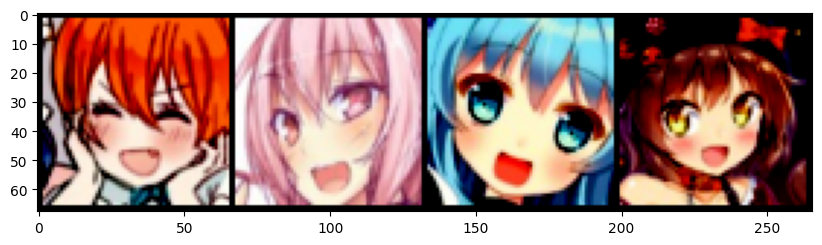

In [4]:
temp_dataset = get_dataset(os.path.join(workspace_dir, 'faces'))

images = [temp_dataset[i] for i in range(4)]
grid_img = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(10,10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

# Model setting
In this section, we will create models and trainer.

## Create model
In this section, we will create models for Generator and Discriminator

### Generator

In [5]:
# Generator

class Generator(nn.Module):
    """
    Input shape: (batch, in_dim)
    Output shape: (batch, 3, 64, 64)
    """
    def __init__(self, in_dim, feature_dim=64):
        super().__init__()

        #input: (batch, 100)
        self.l1 = nn.Sequential(
            nn.Linear(in_dim, feature_dim * 8 * 4 * 4, bias=False),
            nn.BatchNorm1d(feature_dim * 8 * 4 * 4),
            nn.ReLU()
        )
        self.l2 = nn.Sequential(
            self.dconv_bn_relu(feature_dim * 8, feature_dim * 4),               #(batch, feature_dim * 16, 8, 8)
            self.dconv_bn_relu(feature_dim * 4, feature_dim * 2),               #(batch, feature_dim * 16, 16, 16)
            self.dconv_bn_relu(feature_dim * 2, feature_dim),                   #(batch, feature_dim * 16, 32, 32)
        )
        self.l3 = nn.Sequential(
            nn.ConvTranspose2d(feature_dim, 3, kernel_size=5, stride=2,
                               padding=2, output_padding=1, bias=False),
            nn.Tanh()
        )
        self.apply(weights_init)
    def dconv_bn_relu(self, in_dim, out_dim):
        return nn.Sequential(
            nn.ConvTranspose2d(in_dim, out_dim, kernel_size=5, stride=2,
                               padding=2, output_padding=1, bias=False),        #double height and width
            nn.BatchNorm2d(out_dim),
            nn.ReLU(True)
        )
    def forward(self, x):
        y = self.l1(x)
        y = y.view(y.size(0), -1, 4, 4)
        y = self.l2(y)
        y = self.l3(y)
        return y

### Discriminator-DCGAN

In [ ]:
# # Discriminator
# class Discriminator(nn.Module):
#     """
#     Input shape: (batch, 3, 64, 64)
#     Output shape: (batch)
#     """
#     def __init__(self, in_dim, feature_dim=64):
#         super(Discriminator, self).__init__()

#         #input: (batch, 3, 64, 64)
#         """
#         NOTE FOR SETTING DISCRIMINATOR:

#         Remove last sigmoid layer for WGAN
#         """
#         self.l1 = nn.Sequential(
#             nn.Conv2d(in_dim, feature_dim, kernel_size=4, stride=2, padding=1), #(batch, 3, 32, 32)
#             nn.LeakyReLU(0.2),
#             self.conv_bn_lrelu(feature_dim, feature_dim * 2),                   #(batch, 3, 16, 16)
#             self.conv_bn_lrelu(feature_dim * 2, feature_dim * 4),               #(batch, 3, 8, 8)
#             self.conv_bn_lrelu(feature_dim * 4, feature_dim * 8),               #(batch, 3, 4, 4)
#             nn.Conv2d(feature_dim * 8, 1, kernel_size=4, stride=1, padding=0),
#             nn.Sigmoid()
#         )
#         self.apply(weights_init)
#     def conv_bn_lrelu(self, in_dim, out_dim):
#         """
#         NOTE FOR SETTING DISCRIMINATOR:

#         You can't use nn.Batchnorm for WGAN-GP
#         Use nn.InstanceNorm2d instead
#         """

#         return nn.Sequential(
#             nn.Conv2d(in_dim, out_dim, 4, 2, 1),
#             nn.BatchNorm2d(out_dim),
#             nn.LeakyReLU(0.2),
#         )
#     def forward(self, x):
#         y = self.l1(x)
#         y = y.view(-1)
#         return y

### Discriminator-WGAN

In [6]:
# # Discriminator
# class Discriminator(nn.Module):
#     """
#     Input shape: (batch, 3, 64, 64)
#     Output shape: (batch)
#     """
#     def __init__(self, in_dim, feature_dim=64):
#         super(Discriminator, self).__init__()

#         #input: (batch, 3, 64, 64)
#         """
#         NOTE FOR SETTING DISCRIMINATOR:

#         Remove last sigmoid layer for WGAN
#         """
#         self.l1 = nn.Sequential(
#             nn.Conv2d(in_dim, feature_dim, kernel_size=4, stride=2, padding=1), #(batch, 3, 32, 32)
#             nn.LeakyReLU(0.2),
#             self.conv_bn_lrelu(feature_dim, feature_dim * 2),                   #(batch, 3, 16, 16)
#             self.conv_bn_lrelu(feature_dim * 2, feature_dim * 4),               #(batch, 3, 8, 8)
#             self.conv_bn_lrelu(feature_dim * 4, feature_dim * 8),               #(batch, 3, 4, 4)
#             nn.Conv2d(feature_dim * 8, 1, kernel_size=4, stride=1, padding=0),
#             # nn.Sigmoid()
#         )
#         self.apply(weights_init)
#     def conv_bn_lrelu(self, in_dim, out_dim):
#         """
#         NOTE FOR SETTING DISCRIMINATOR:

#         You can't use nn.Batchnorm for WGAN-GP
#         Use nn.InstanceNorm2d instead
#         """

#         return nn.Sequential(
#             nn.Conv2d(in_dim, out_dim, 4, 2, 1),
#             nn.BatchNorm2d(out_dim),
#             nn.LeakyReLU(0.2),
#         )
#     def forward(self, x):
#         y = self.l1(x)
#         y = y.view(-1)
#         return y

### Discriminator-WGANGP

In [14]:
# Discriminator
class Discriminator(nn.Module):
    """
    Input shape: (batch, 3, 64, 64)
    Output shape: (batch)
    """
    def __init__(self, in_dim, feature_dim=64):
        super(Discriminator, self).__init__()

        #input: (batch, 3, 64, 64)
        """
        NOTE FOR SETTING DISCRIMINATOR:

        Remove last sigmoid layer for WGAN
        """
        self.l1 = nn.Sequential(
            nn.Conv2d(in_dim, feature_dim, kernel_size=4, stride=2, padding=1), #(batch, 3, 32, 32)
            nn.LeakyReLU(0.2),
            self.conv_bn_lrelu(feature_dim, feature_dim * 2),                   #(batch, 3, 16, 16)
            self.conv_bn_lrelu(feature_dim * 2, feature_dim * 4),               #(batch, 3, 8, 8)
            self.conv_bn_lrelu(feature_dim * 4, feature_dim * 8),               #(batch, 3, 4, 4)
            nn.Conv2d(feature_dim * 8, 1, kernel_size=4, stride=1, padding=0),
            # nn.Sigmoid()
        )
        self.apply(weights_init)
    def conv_bn_lrelu(self, in_dim, out_dim):
        """
        NOTE FOR SETTING DISCRIMINATOR:

        You can't use nn.Batchnorm for WGAN-GP
        Use nn.InstanceNorm2d instead
        """

        return nn.Sequential(
            nn.Conv2d(in_dim, out_dim, 4, 2, 1),
            # nn.BatchNorm2d(out_dim),
            nn.InstanceNorm2d(out_dim),
            nn.LeakyReLU(0.2),
        )
    def forward(self, x):
        y = self.l1(x)
        y = y.view(-1)
        return y

### Weight initialization

In [15]:
# setting for weight init function
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

## Create trainer
In this section, we will create a trainer which contains following functions:
1. prepare_environment: prepare the overall environment, construct the models, create directory for the log and ckpt
2. train: train for generator and discriminator, you can try to modify the code here to construct WGAN or WGAN-GP
3. inference: after training, you can pass the generator ckpt path into it and the function will save the result for you

In [16]:
class TrainerGAN():
    def __init__(self, config):
        self.config = config

        self.G = Generator(100)
        self.D = Discriminator(3)

        self.loss = nn.BCELoss()

        """
        NOTE FOR SETTING OPTIMIZER:

        GAN: use Adam optimizer
        WGAN: use RMSprop optimizer
        WGAN-GP: use Adam optimizer
        """
        self.opt_D = torch.optim.Adam(self.D.parameters(), lr=self.config["lr"], betas=(0.5, 0.999))
        self.opt_G = torch.optim.Adam(self.G.parameters(), lr=self.config["lr"], betas=(0.5, 0.999))

        # self.opt_D = torch.optim.RMSprop(self.D.parameters(), lr=self.config["lr"])
        # self.opt_G = torch.optim.RMSprop(self.G.parameters(), lr=self.config["lr"])

        self.dataloader = None
        self.log_dir = os.path.join(self.config["workspace_dir"], 'logs')
        self.ckpt_dir = os.path.join(self.config["workspace_dir"], 'checkpoints')

        FORMAT = '%(asctime)s - %(levelname)s: %(message)s'
        logging.basicConfig(level=logging.INFO,
                            format=FORMAT,
                            datefmt='%Y-%m-%d %H:%M')

        self.steps = 0
        self.z_samples = Variable(torch.randn(100, self.config["z_dim"])).cuda()

    def prepare_environment(self):
        """
        Use this funciton to prepare function
        """
        os.makedirs(self.log_dir, exist_ok=True)
        os.makedirs(self.ckpt_dir, exist_ok=True)

        # update dir by time
        time = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
        self.log_dir = os.path.join(self.log_dir, time+f'_{self.config["model_type"]}')
        self.ckpt_dir = os.path.join(self.ckpt_dir, time+f'_{self.config["model_type"]}')
        os.makedirs(self.log_dir)
        os.makedirs(self.ckpt_dir)

        # create dataset by the above function
        dataset = get_dataset(os.path.join(self.config["workspace_dir"], 'faces'))
        self.dataloader = DataLoader(dataset, batch_size=self.config["batch_size"], shuffle=True, num_workers=2)

        # model preparation
        self.G = self.G.cuda()
        self.D = self.D.cuda()
        self.G.train()
        self.D.train()

    def gp(self, r_imgs, f_imgs):
        Tensor = torch.cuda.FloatTensor
        alpha = Tensor(np.random.random((r_imgs.size(0), 1, 1, 1)))
        interpolates = (alpha*r_imgs + (1 - alpha)*f_imgs).requires_grad_(True)
        d_interpolates = self.D(interpolates)
        fake = Variable(Tensor(r_imgs.shape[0]).fill_(1.0), requires_grad=False)
        gradients = autograd.grad(
            outputs=d_interpolates,
            inputs=interpolates,
            grad_outputs=fake,
            create_graph=True,
            retain_graph=True,
            only_inputs=True,
        )[0]

        gradients = gradients.view(gradients.size(0), -1)
        gradient_penalty = ((gradients.norm(1, dim=1) - 1)**2).mean()
        return gradient_penalty

    def train(self):
        """
        Use this function to train generator and discriminator
        """
        self.prepare_environment()

        for e, epoch in enumerate(range(self.config["n_epoch"])):
            progress_bar = tqdm(self.dataloader)
            progress_bar.set_description(f"Epoch {e+1}")
            for i, data in enumerate(progress_bar):
                imgs = data.cuda()
                bs = imgs.size(0)

                # *********************
                # *    Train D        *
                # *********************
                z = Variable(torch.randn(bs, self.config["z_dim"])).cuda()
                r_imgs = Variable(imgs).cuda()
                f_imgs = self.G(z)
                r_label = torch.ones((bs)).cuda()
                f_label = torch.zeros((bs)).cuda()


                # Discriminator forwarding
                r_logit = self.D(r_imgs)
                f_logit = self.D(f_imgs)

                """
                NOTE FOR SETTING DISCRIMINATOR LOSS:

                GAN:
                    loss_D = (r_loss + f_loss)/2
                WGAN:
                    loss_D = -torch.mean(r_logit) + torch.mean(f_logit)
                WGAN-GP:
                    gradient_penalty = self.gp(r_imgs, f_imgs)
                    loss_D = -torch.mean(r_logit) + torch.mean(f_logit) + gradient_penalty
                """
                # Loss for discriminator
                # r_loss = self.loss(r_logit, r_label)
                # f_loss = self.loss(f_logit, f_label)
                # loss_D = (r_loss + f_loss) / 2

                # loss_D = -torch.mean(r_logit) + torch.mean(f_logit)

                gradient_penalty = self.gp(r_imgs, f_imgs)
                loss_D = -torch.mean(r_logit) + torch.mean(f_logit) + gradient_penalty

                # Discriminator backwarding
                self.D.zero_grad()
                loss_D.backward()

                # 裁剪梯度范数
                # utils.clip_grad_norm_(self.D.parameters(), max_norm=1.0)
                self.opt_D.step()

                """
                NOTE FOR SETTING WEIGHT CLIP:

                WGAN: below code
                """
                # for p in self.D.parameters():
                #     p.data.clamp_(-self.config["clip_value"], self.config["clip_value"])

                """
                打印每个layer的梯度
                """
                # for name, param in self.D.named_parameters():
                #   if 'weight' in name and param.grad is not None:
                #     print(f"{name} grad norm: {param.grad.norm().item()}")



                # *********************
                # *    Train G        *
                # *********************
                if self.steps % self.config["n_critic"] == 0:
                    # Generate some fake images.
                    z = Variable(torch.randn(bs, self.config["z_dim"])).cuda()
                    f_imgs = self.G(z)

                    # Generator forwarding
                    f_logit = self.D(f_imgs)


                    """
                    NOTE FOR SETTING LOSS FOR GENERATOR:

                    GAN: loss_G = self.loss(f_logit, r_label)
                    WGAN: loss_G = -torch.mean(self.D(f_imgs))
                    WGAN-GP: loss_G = -torch.mean(self.D(f_imgs))
                    """
                    # Loss for the generator.
                    # loss_G = self.loss(f_logit, r_label)
                    loss_G = -torch.mean(self.D(f_imgs))

                    # Generator backwarding
                    self.G.zero_grad()
                    loss_G.backward()

                    # utils.clip_grad_norm_(self.G.parameters(), max_norm=1.0)
                    self.opt_G.step()

                if self.steps % 10 == 0:
                    progress_bar.set_postfix(loss_G=loss_G.item(), loss_D=loss_D.item())
                self.steps += 1

            self.G.eval()
            f_imgs_sample = (self.G(self.z_samples).data + 1) / 2.0
            filename = os.path.join(self.log_dir, f'Epoch_{epoch+1:03d}.jpg')
            torchvision.utils.save_image(f_imgs_sample, filename, nrow=10)
            logging.info(f'Save some samples to {filename}.')

            # Show some images during training.
            grid_img = torchvision.utils.make_grid(f_imgs_sample.cpu(), nrow=10)
            plt.figure(figsize=(10,10))
            plt.imshow(grid_img.permute(1, 2, 0))
            plt.show()

            self.G.train()

            if (e+1) % 5 == 0 or e == 0:
                # Save the checkpoints.
                torch.save(self.G.state_dict(), os.path.join(self.ckpt_dir, f'G_{e}.pth'))
                torch.save(self.D.state_dict(), os.path.join(self.ckpt_dir, f'D_{e}.pth'))

        logging.info('Finish training')

    def inference(self, G_path, n_generate=1000, n_output=30, show=False):
        """
        1. G_path is the path for Generator ckpt
        2. You can use this function to generate final answer
        """

        self.G.load_state_dict(torch.load(G_path))
        self.G.cuda()
        self.G.eval()
        z = Variable(torch.randn(n_generate, self.config["z_dim"])).cuda()
        imgs = (self.G(z).data + 1) / 2.0

        os.makedirs('output', exist_ok=True)
        for i in range(n_generate):
            torchvision.utils.save_image(imgs[i], f'output/{i+1}.jpg')

        if show:
            row, col = n_output//10 + 1, 10
            grid_img = torchvision.utils.make_grid(imgs[:n_output].cpu(), nrow=row)
            plt.figure(figsize=(row, col))
            plt.imshow(grid_img.permute(1, 2, 0))
            plt.show()

# Train
In this section, we will first set the config for trainer, then use it to train generator and discriminator

## Set config

In [17]:
config = {
    "model_type": "WGAN",
    "batch_size": 64,
    "lr": 1e-4,
    "n_epoch": 1,
    "n_critic": 2,
    "z_dim": 100,
    "workspace_dir": workspace_dir, # define in the environment setting
    "clip_value": 0.1
}

## Start to train

Epoch 1:   0%|          | 0/1115 [00:00<?, ?it/s]<ipython-input-16-59d349ed4065>:61: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  alpha = Tensor(np.random.random((r_imgs.size(0), 1, 1, 1)))
Epoch 1:   0%|          | 1/1115 [00:00<11:20,  1.64it/s, loss_D=4.06e+5, loss_G=-1.66]

l1.0.weight grad norm: 1711372.5
l1.2.0.weight grad norm: 827243.0625
l1.3.0.weight grad norm: 464326.4375
l1.4.0.weight grad norm: 411017.375
l1.5.weight grad norm: 603481.0


Epoch 1:   0%|          | 3/1115 [00:00<04:50,  3.83it/s, loss_D=4.06e+5, loss_G=-1.66]

l1.0.weight grad norm: 1433499.0
l1.2.0.weight grad norm: 711618.125
l1.3.0.weight grad norm: 393292.625
l1.4.0.weight grad norm: 339213.4375
l1.5.weight grad norm: 483258.3125
l1.0.weight grad norm: 1180896.5
l1.2.0.weight grad norm: 579705.0625
l1.3.0.weight grad norm: 323889.25
l1.4.0.weight grad norm: 278101.78125
l1.5.weight grad norm: 393207.53125


Epoch 1:   0%|          | 5/1115 [00:01<03:56,  4.69it/s, loss_D=4.06e+5, loss_G=-1.66]

...

l1.0.weight grad norm: 348.2398681640625
l1.2.0.weight grad norm: 158.8392333984375
l1.3.0.weight grad norm: 113.0177001953125
l1.4.0.weight grad norm: 466.0368957519531
l1.5.weight grad norm: 1050.8050537109375
l1.0.weight grad norm: 325.646484375
l1.2.0.weight grad norm: 165.7533721923828
l1.3.0.weight grad norm: 105.83231353759766
l1.4.0.weight grad norm: 285.8496398925781
l1.5.weight grad norm: 587.3521728515625


Epoch 1: 100%|█████████▉| 1113/1115 [03:35<00:00,  5.46it/s, loss_D=76.4, loss_G=-3.87]

l1.0.weight grad norm: 235.23406982421875
l1.2.0.weight grad norm: 138.1572723388672
l1.3.0.weight grad norm: 90.16213989257812
l1.4.0.weight grad norm: 263.4698791503906
l1.5.weight grad norm: 488.2125549316406
l1.0.weight grad norm: 364.864990234375
l1.2.0.weight grad norm: 220.34300231933594
l1.3.0.weight grad norm: 155.2262725830078
l1.4.0.weight grad norm: 448.0989990234375
l1.5.weight grad norm: 899.6769409179688


Epoch 1: 100%|██████████| 1115/1115 [03:35<00:00,  5.18it/s, loss_D=76.4, loss_G=-3.87]

l1.0.weight grad norm: 238.1302032470703
l1.2.0.weight grad norm: 133.4261474609375
l1.3.0.weight grad norm: 87.56192779541016
l1.4.0.weight grad norm: 265.9677429199219
l1.5.weight grad norm: 496.361083984375
l1.0.weight grad norm: 485.529541015625
l1.2.0.weight grad norm: 235.1840362548828
l1.3.0.weight grad norm: 187.5154571533203
l1.4.0.weight grad norm: 823.1803588867188
l1.5.weight grad norm: 1720.6566162109375


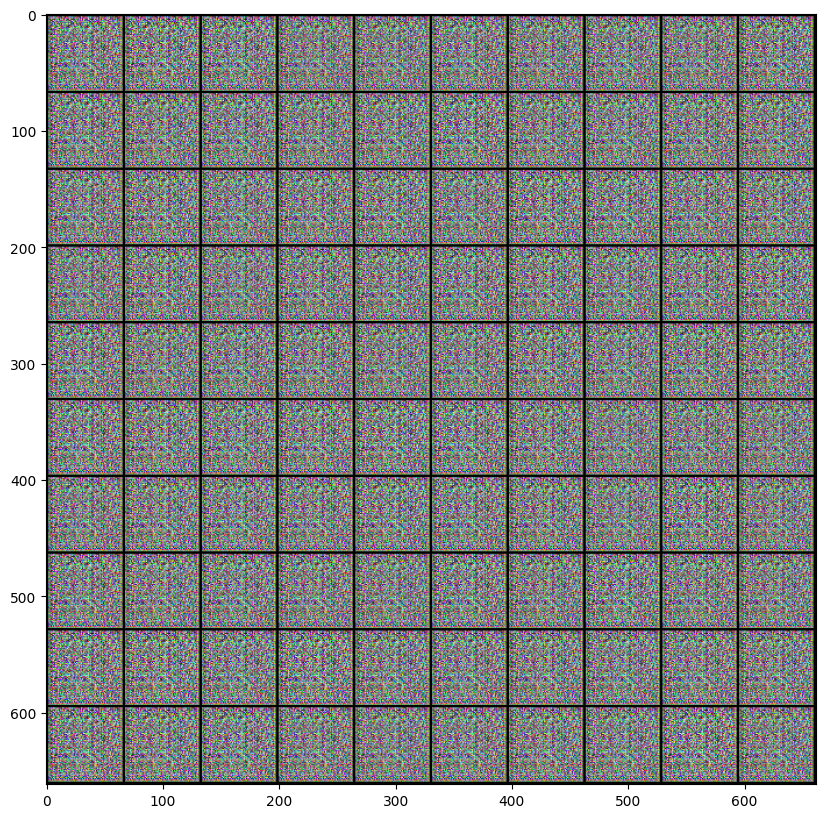

In [18]:
trainer = TrainerGAN(config)
trainer.train()

In [11]:
print(trainer.D)

Discriminator(
  (l1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (4): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (5): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
  )
)


# StyleGAN


In [ ]:
# !pip install stylegan2_pytorch
!pip install --upgrade stylegan2_pytorch  # 安装最新版（支持--num-images）

In [ ]:
!stylegan2_pytorch \
    --data ./faces \
    --name my_stylegan2 \
    --image-size 64 \
    --batch-size 64 \
    --num-train-steps 10 \
    --save-every 5 \
    --trunc-psi 0.7

continuing from previous epoch - 2
loading from version 1.9.0
my_stylegan2<./faces>: 100% 10/10 [00:00<?, ?it/s]


# Inference
In this section, we will use trainer to train model

## Inference through trainer

In [ ]:
# save the 1000 images into ./output folder
# trainer.inference(f'{workspace_dir}/checkpoints/2025-04-05_15-37-38_GAN/G_49.pth') # you have to modify the path when running this line

In [ ]:
os.makedirs('output', exist_ok=True)

In [ ]:
!stylegan2_pytorch \
    --name my_stylegan2 \
    --generate \
    --num_generate 10 \
    --trunc-psi 0.7 \
    --results-dir ./output

continuing from previous epoch - 2
loading from version 1.9.0
100% 10/10 [00:04<00:00,  2.03it/s]
sample images generated at ./output/my_stylegan2/generated-04-11-2025_10-30-16


In [ ]:
!stylegan2_pytorch --help

INFO: Showing help with the command 'stylegan2_pytorch -- --help'.

NAME
    stylegan2_pytorch

SYNOPSIS
    stylegan2_pytorch <flags>

FLAGS
    --data=DATA
        Default: './data'
    --results_dir=RESULTS_DIR
        Default: './results'
    --models_dir=MODELS_DIR
        Default: './models'
    --name=NAME
        Default: 'default'
    --new=NEW
        Default: False
    --load_from=LOAD_FROM
        Default: -1
    --image_size=IMAGE_SIZE
        Default: 128
    --network_capacity=NETWORK_CAPACITY
        Default: 16
    --fmap_max=FMAP_MAX
        Default: 512
    --transparent=TRANSPARENT
        Default: False
    -b, --batch_size=BATCH_SIZE
        Default: 5
    --gradient_accumulate_every=GRADIENT_ACCUMULATE_EVERY
        Default: 6
    --num_train_steps=NUM_TRAIN_STEPS
        Default: 150000
    --learning_rate=LEARNING_RATE
        Default: 0.0002
    --lr_mlp=LR_MLP
        Default: 0.1
    --ttur_mult=TTUR_MULT
        Default: 1.5
    --rel_disc_loss=REL_DISC_LOS

## Prepare .tar file for submission

In [ ]:
# %cd output
# !tar -zcf ../submission.tgz *.jpg
# %cd ..

In [ ]:
# !tar -xzvf /content/submission.tgz
# !mkdir /content/simple  # 绝对路径
# !tar -xzvf /content/submission.tgz -C /content/simple

In [ ]:
!pip install pytorch-fid
!wget https://raw.githubusercontent.com/nagadomi/lbpcascade_animeface/master/lbpcascade_animeface.xml -O lbpcascade_animeface.xml

--2025-04-11 09:19:27--  https://raw.githubusercontent.com/nagadomi/lbpcascade_animeface/master/lbpcascade_animeface.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 246945 (241K) [text/plain]
Saving to: ‘lbpcascade_animeface.xml’

lbpcascade_animefac 100%[===================>] 241.16K  --.-KB/s    in 0.005s  

2025-04-11 09:19:28 (44.9 MB/s) - ‘lbpcascade_animeface.xml’ saved [246945/246945]



In [ ]:
!pip install pytorch-fid ultralytics
!wget https://github.com/MagicalKyaru/yolov8_animeface/releases/download/v1/yolov8x6_animeface.pt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 45.7 MB/s eta 0:00:00
--2025-04-11 09:08:36--  https://github.com/MagicalKyaru/yolov8_animeface/releases/download/v1/yolov8x6_animeface.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/Fuyucch1/yolov8_animeface/releases/download/v1/yolov8x6_animeface.pt [following]
--2025-04-11 09:08:37--  https://github.com/Fuyucch1/yolov8_animeface/releases/download/v1/yolov8x6_animeface.pt
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://objects.githubusercontent.com/github-production-release-asset-2e65be/754149685/213c9a83-4bb9-4825-aaeb-4f231e613b62?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=releaseassetproduction%2F20250411%2Fus-east-1%2Fs3%2Faws4_request&X-Amz-Date=20250411T090837Z&X-Amz-Expires=300&

In [ ]:
from ultralytics import YOLO
from pytorch_fid import fid_score
import os

def calculate_fid(real_images_path, generated_images_path):
    """
    Calculate FID score between real and generated images.

    :param real_images_path: Path to the directory containing real images.
    :param generated_images_path: Path to the directory containing generated images.
    :return: FID score
    """
    fid = fid_score.calculate_fid_given_paths([real_images_path, generated_images_path], batch_size=50, device='cuda', dims=2048)
    return fid

def calculate_afd(generated_images_path, save=True):
    """
    Calculate AFD (Anime Face Detection) score for generated images.

    :param generated_images_path: Path to the directory containing generated images.
    :return: AFD score (percentage of images detected as anime faces)
    """
    results = yolov8_animeface.predict(generated_images_path, save=save, conf=0.8, iou=0.8, imgsz=64)

    anime_faces_detected = 0
    total_images = len(results)

    for result in results:
        if len(result.boxes) > 0:
            anime_faces_detected += 1

    afd_score = anime_faces_detected / total_images
    return afd_score

In [ ]:
# Calculate and print FID and AFD with optional visualization
yolov8_animeface = YOLO('yolov8x6_animeface.pt')
real_images_path = './faces'  # Replace with the path to real images

fid = calculate_fid(real_images_path, '/content/output/my_stylegan2')
afd = calculate_afd('/content/output/my_stylegan2')

  0%|          | 0/2 [00:00<?, ?it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/collate.py", line 155, in collate
    return collate_fn_map[elem_type](batch, collate_fn_map=collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/

In [ ]:
print(f'FID: {fid}')
print(f'AFD: {afd}')

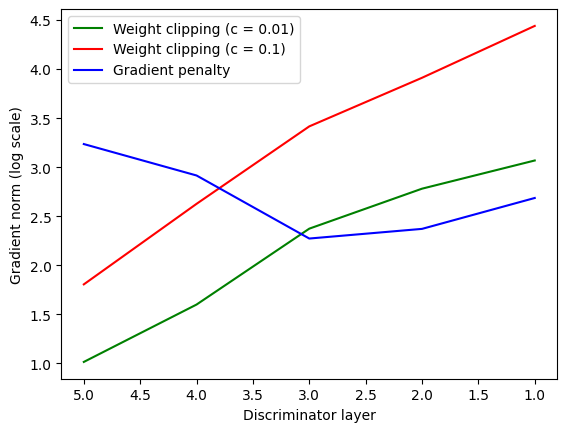

In [20]:
clip_1 = [27519.07421875, 8148.35888671875, 2605.486083984375, 423.2121887207031, 63.975807189941406]

clip_01 = [1170.3809814453125, 603.9940795898438, 236.42465209960938, 39.837188720703125, 10.367115020751953]

gp = [485.529541015625, 235.1840362548828, 187.5154571533203, 823.1803588867188, 1720.6566162109375]

import matplotlib.pyplot as plt
import numpy as np

layers = np.arange(1, 6)

plt.plot(layers, np.log10(clip_01), label='Weight clipping (c = 0.01)', color='green')
plt.plot(layers, np.log10(clip_1), label='Weight clipping (c = 0.1)', color='red')
plt.plot(layers, np.log10(gp), label='Gradient penalty', color='blue')

plt.gca().invert_xaxis()  # 让第13层在左边
plt.ylabel("Gradient norm (log scale)")
plt.xlabel("Discriminator layer")
plt.legend()
plt.show()
